mitko1


# Bird data + KNMI weather merge

Here we want to add weather info to the bird dataset, so later we can check things like - do cormorants show up more often when it is warm, or when it rains?

## What we are importing from KNMI

- From KNMI - the Dutch weather service - https://daggegevens.knmi.nl/klimatologie/daggegevens
- File - `KNMI.txt` (already saved in this folder)
- Dates - 2010-01-01 until 2026-05-18

**Stations** (10, spread around the Netherlands so every bird location has one nearby):

240 Schiphol, 260 De Bilt, 270 Leeuwarden, 280 Eelde, 290 Twenthe, 310 Vlissingen, 330 Hoek van Holland, 344 Rotterdam, 380 Maastricht, 391 Arcen

**Fields** (8 weather values per day):

- TG - mean temperature
- TN - min temperature
- TX - max temperature
- RH - rain
- FG - wind
- UG - humidity
- SQ - sunshine
- Q - solar radiation

## KNMI dataset


In [1]:
import pandas as pd

knmi = pd.read_csv(
    "KNMI.txt",
    comment="#",
    names=["STN", "YYYYMMDD", "FG", "TG", "TN", "TX", "SQ", "Q", "RH", "UG"],
    skipinitialspace=True,
)

print("Shape:", knmi.shape)
knmi.head(11)

Shape: (59589, 10)


,STN,YYYYMMDD,FG,TG,TN,TX,SQ,Q,RH,UG
0,240,20100101,46.0,-16.0,-63.0,8.0,50.0,343.0,-1.0,82.0
1,240,20100102,43.0,-6.0,-55.0,16.0,3.0,146.0,7.0,95.0
2,240,20100103,28.0,-34.0,-75.0,-5.0,52.0,360.0,0.0,91.0
3,240,20100104,41.0,-15.0,-51.0,12.0,14.0,201.0,3.0,97.0
4,240,20100105,39.0,-2.0,-22.0,20.0,8.0,195.0,4.0,95.0
5,240,20100106,34.0,-28.0,-66.0,3.0,55.0,449.0,28.0,95.0
6,240,20100107,27.0,-48.0,-115.0,-24.0,47.0,376.0,-1.0,94.0
7,240,20100108,40.0,-57.0,-138.0,-22.0,21.0,246.0,-1.0,95.0
8,240,20100109,100.0,-18.0,-45.0,-4.0,0.0,198.0,6.0,88.0
9,240,20100110,70.0,-1.0,-6.0,4.0,0.0,80.0,17.0,95.0


## Why we can not merge the two files yet

The two files do not match, so we need to clean them up first:

- Dates look different. Bird file uses `2010-01-01`, KNMI uses `20100101`.
- KNMI numbers are 10x too bigger.Temperature is in 0.1 °C, so 125 means 12.5 °C. We need to divide by 10.
- KNMI uses `-1` to mean "almost nothing" for the rain and sunshine. We need to turn those into 0.
- The KNMI file has comment lines at the top before the real data. We need to skip them when loading.
- Bird data has thousands of locations on a grid, KNMI only has 10 stations. For each bird location we need to find the nearest station first.
- One KNMI station (391 Arcen) stops in September 2025 while the others go up to mid-May 2026. A small fraction of bird rows assigned to Arcen for Oct-Dec 2025 will end up with empty weather values.

We will fix all of this in the next part.

## Step 1 - Load the bird + habitat data

We start with the dataset from notebook 2. We tell pandas to parse `eventDate` as a real date right away for faster load time.

In [2]:
df = pd.read_csv(
    "bird_and_habitats.csv",
    parse_dates=["eventDate"],
    low_memory=False,
)

print("Shape:", df.shape)
df.head(3)

Shape: (12558756, 15)


,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Phalacrocorax carbo,agricultural,built,coast,forest,other,sand/heather,water,wetland,main_habitat
0,50.75,5.65,2010-01-01,0.0,0,0,1.7747,0.0568,0.0,0.0616,0.0582,0.0,0.4688,0.0,agricultural
1,50.75,5.65,2010-01-02,25.0,25,1,1.7747,0.0568,0.0,0.0616,0.0582,0.0,0.4688,0.0,agricultural
2,50.75,5.65,2010-01-03,3.0,3,0,1.7747,0.0568,0.0,0.0616,0.0582,0.0,0.4688,0.0,agricultural


## Add time features from the date

Cormorants are migratory, so the time of year matters a lot. We pull two simple features straight out of `eventDate` - no extra data needed:

- month
- day_of_year

In [3]:
df["month"] = df["eventDate"].dt.month
df["day_of_year"] = df["eventDate"].dt.dayofyear

df[["eventDate", "month", "day_of_year"]].head(3)

,eventDate,month,day_of_year
0,2010-01-01,1,1
1,2010-01-02,1,2
2,2010-01-03,1,3


## Step 2 - Clean up the KNMI data

Three small fixes so the numbers are real:

1. Turn `YYYYMMDD` format into the same format as the original dataset.
2. Replace `-1` in `RH` and `SQ` with `0` (KNMI uses -1 to mean "less than 0.05").
3. Divide the tenths columns by 10 (`TG`, `TN`, `TX`, `FG`, `RH`, `SQ`).

`UG` (humidity in %) and `Q` (radiation in J/cm²) are already in their final units.

In [ ]:
knmi["date"] = pd.to_datetime(knmi["YYYYMMDD"], format="%Y%m%d")

knmi["RH"] = knmi["RH"].replace(-1, 0)
knmi["SQ"] = knmi["SQ"].replace(-1, 0)

for col in ["TG", "TN", "TX", "FG", "RH", "SQ"]:
    knmi[col] = knmi[col] / 10

knmi.head(5)knmi["date"] = pd.to_datetime(knmi["YYYYMMDD"], format="%Y%m%d")

knmi["RH"] = knmi["RH"].replace(-1, 0)
knmi["SQ"] = knmi["SQ"].replace(-1, 0)

for col in ["TG", "TN", "TX", "FG", "RH", "SQ"]:
    knmi[col] = knmi[col] / 10

knmi.head(5)

,STN,YYYYMMDD,FG,TG,TN,TX,SQ,Q,RH,UG,date
0,240,20100101,4.6,-1.6,-6.3,0.8,5.0,343.0,0.0,82.0,2010-01-01
1,240,20100102,4.3,-0.6,-5.5,1.6,0.3,146.0,0.7,95.0,2010-01-02
2,240,20100103,2.8,-3.4,-7.5,-0.5,5.2,360.0,0.0,91.0,2010-01-03
3,240,20100104,4.1,-1.5,-5.1,1.2,1.4,201.0,0.3,97.0,2010-01-04
4,240,20100105,3.9,-0.2,-2.2,2.0,0.8,195.0,0.4,95.0,2010-01-05


## Step 3 - Find the nearest weather station for each bird location

Bird data has thousands of grid cells but KNMI only has 10 stations where data was collectef from. For each unique (lat, lon) we pick the closest station using the haversine formula (real distance on a sphere, not flat geometry).

Station coordinates come from the header of `KNMI.txt`.

In [5]:
import numpy as np

STATIONS = {
    240: (52.318, 4.790),   # Schiphol
    260: (52.100, 5.180),   # De Bilt
    270: (53.224, 5.752),   # Leeuwarden
    280: (53.125, 6.585),   # Eelde
    290: (52.274, 6.891),   # Twenthe
    310: (51.442, 3.596),   # Vlissingen
    330: (51.992, 4.122),   # Hoek van Holland
    344: (51.962, 4.447),   # Rotterdam
    380: (50.906, 5.762),   # Maastricht
    391: (51.498, 6.197),   # Arcen
}

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dp = np.radians(lat2 - lat1)
    dl = np.radians(lon2 - lon1)
    a = np.sin(dp/2)**2 + np.cos(p1) * np.cos(p2) * np.sin(dl/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

cells = df[["decimalLatitude", "decimalLongitude"]].drop_duplicates().reset_index(drop=True)

stn_ids  = np.array(list(STATIONS.keys()))
stn_lats = np.array([s[0] for s in STATIONS.values()])
stn_lons = np.array([s[1] for s in STATIONS.values()])

dist = haversine_km(
    cells["decimalLatitude"].values[:, None],
    cells["decimalLongitude"].values[:, None],
    stn_lats[None, :],
    stn_lons[None, :],
)
cells["STN"] = stn_ids[dist.argmin(axis=1)]

print("Grid cells per station:")
print(cells["STN"].value_counts().sort_index())
cells.head()

Grid cells per station:
STN
240    198
260    345
270    286
280    306
290    266
310    160
330     59
344    202
380    120
391    207
Name: count, dtype: int64


,decimalLatitude,decimalLongitude,STN
0,50.75,5.65,380
1,50.75,5.70,380
2,50.75,5.75,380
3,50.75,5.80,380
4,50.75,5.85,380


## Step 4 - Merge bird + KNMI

Two joins:

1. Attach the nearest `STN` to every bird row (join on lat, lon).
2. Attach the daily weather for that station (join on STN + date).

After this every bird row has 8 new weather columns.

In [6]:
# Drop any leftover columns from a previous run so this cell is safe to re-run
leftover = ["STN", "STN_x", "STN_y", "TG", "TN", "TX", "RH", "FG", "UG", "SQ", "Q", "date"]
df = df.drop(columns=[c for c in leftover if c in df.columns])

df = df.merge(cells, on=["decimalLatitude", "decimalLongitude"], how="left")

df = df.merge(
    knmi[["STN", "date", "TG", "TN", "TX", "RH", "FG", "UG", "SQ", "Q"]],
    left_on=["STN", "eventDate"],
    right_on=["STN", "date"],
    how="left",
).drop(columns=["date"])

print("Final shape:", df.shape)
print(f"Rows with missing weather: {df['TG'].isna().sum():,} "
      f"({df['TG'].isna().mean()*100:.1f}% - expected, station 391 Arcen ends 2025-09-29)")
df.head(5)

Final shape: (12558756, 26)
Rows with missing weather: 21,113 (0.2% - expected, station 391 Arcen ends 2025-09-29)


,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Phalacrocorax carbo,agricultural,built,coast,forest,...,day_of_year,STN,TG,TN,TX,RH,FG,UG,SQ,Q
0,50.75,5.65,2010-01-01,0.0,0,0,1.7747,0.0568,0.0,0.0616,...,1,380,-2.0,-6.1,-1.1,0.1,4.6,91.0,0.0,33.0
1,50.75,5.65,2010-01-02,25.0,25,1,1.7747,0.0568,0.0,0.0616,...,2,380,-2.1,-6.7,0.2,0.2,4.9,90.0,2.7,260.0
2,50.75,5.65,2010-01-03,3.0,3,0,1.7747,0.0568,0.0,0.0616,...,3,380,-3.9,-6.7,0.8,3.0,3.3,92.0,0.3,178.0
3,50.75,5.65,2010-01-04,0.0,0,0,1.7747,0.0568,0.0,0.0616,...,4,380,-5.4,-10.5,-3.0,0.4,3.3,89.0,0.4,218.0
4,50.75,5.65,2010-01-05,0.0,0,0,1.7747,0.0568,0.0,0.0616,...,5,380,-2.3,-4.6,-1.0,0.4,3.5,92.0,0.0,177.0


## Step 5 - Save the merged dataset

Saving as parquet (much smaller and faster to load than CSV for 12+ million rows). The next notebook can just read this file.

In [7]:
df.to_parquet("bird_habitats_weather.parquet", index=False)
print("Saved bird_habitats_weather.parquet")

Saved bird_habitats_weather.parquet


# Some simple visualizations

Now that we have one big table with birds + habitat + weather, let us look at a few quick plots to get a feel for the data.

## Correlation heatmaps (how columns relate to each other)

A correlation heatmap shows how strongly each pair of columns moves together. +1 means they go up together, -1 means one goes up while the other goes down, 0 means no relation.

To keep things readable we split it into two smaller matrices instead of one giant grid:

1. **bird sightings vs habitat**
2. **bird sightings vs weather**

Both keep the three bird/observation columns so you can read each group against the sightings directly.

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Split the variables into groups so we get smaller, easier-to-read matrixes
bird_cols    = ["Phalacrocorax carbo", "total_observations", "speciesgroup_observations"]
habitat_cols = ["agricultural", "built", "coast", "forest", "water", "wetland", "sand/heather"]
weather_cols = ["TG", "TN", "TX", "RH", "FG", "UG", "SQ", "Q"]

pretty = {
    "TG": "Mean temp",
    "TN": "Min temp",
    "TX": "Max temp",
    "RH": "Rain (mm)",
    "FG": "Wind (m/s)",
    "UG": "Humidity (%)",
    "SQ": "Sunshine (h)",
    "Q":  "Solar radiation",
}

def plot_corr(cols, title, method="pearson"):
    corr = df[cols].corr(method=method).rename(index=pretty, columns=pretty)
    plt.figure(figsize=(9, 7))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
                square=True, linewidths=0.3, annot_kws={"size": 8})
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Matrix 1 - bird sightings vs habitat
plot_corr(bird_cols + habitat_cols, "Pearson correlation: bird sightings vs habitat")

# Matrix 2 - bird sightings vs weather
plot_corr(bird_cols + weather_cols, "Pearson correlation: bird sightings vs weather")

KeyboardInterrupt: 

## Non-linear correlation (Spearman)

The heatmaps above use Pearson correlation, which only catches straight-line relationships. Spearman ranks the values first, so it also picks up non-linear monotonic patterns. Same two-matrix split: bird sightings vs habitat, then bird sightings vs weather.

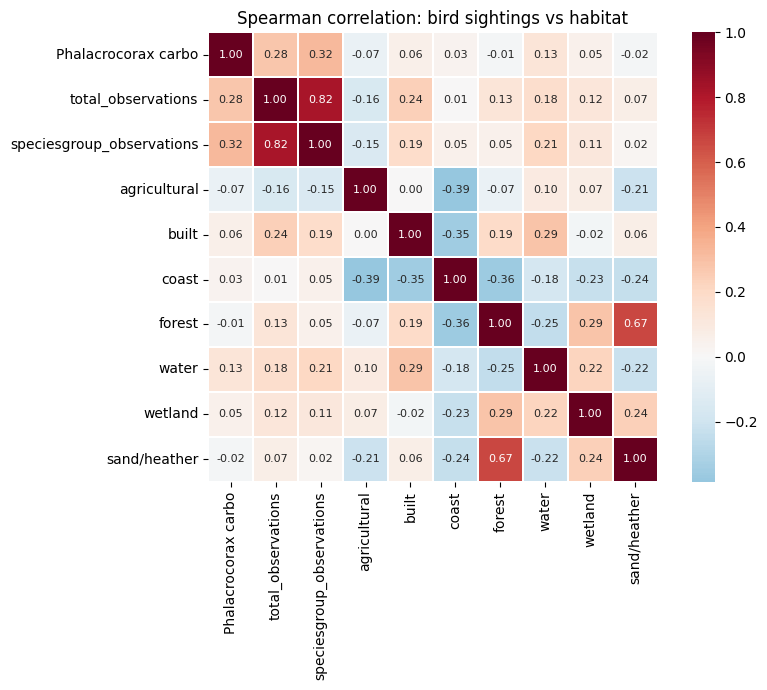

KeyboardInterrupt: 

In [9]:
# Same split as above, but Spearman (rank-based, catches non-linear monotonic patterns)
plot_corr(bird_cols + habitat_cols, "Spearman correlation: bird sightings vs habitat", method="spearman")
plot_corr(bird_cols + weather_cols, "Spearman correlation: bird sightings vs weather", method="spearman")

## Cormorants seen vs temperature

We split the daily mean temperature (TG) into 2 °C ranges and plot the average number of cormorants seen per row in each range.

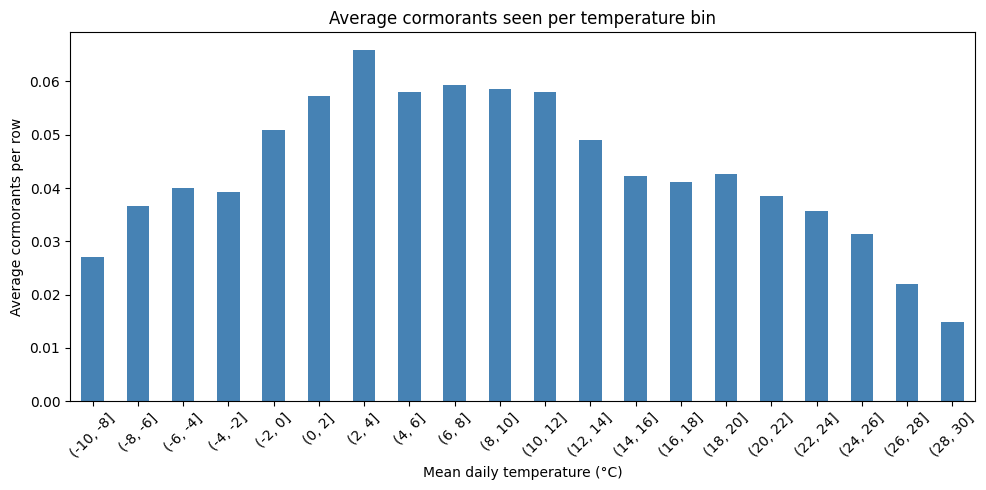

In [ ]:
plot_df = df[["TG", "Phalacrocorax carbo"]].dropna().copy()
plot_df["TG_bin"] = pd.cut(plot_df["TG"], bins=range(-10, 32, 2))
temp_means = plot_df.groupby("TG_bin", observed=True)["Phalacrocorax carbo"].mean()

plt.figure(figsize=(10, 5))
temp_means.plot(kind="bar", color="steelblue")
plt.title("Average cormorants seen per temperature bin")
plt.xlabel("Mean daily temperature (°C)")
plt.ylabel("Average cormorants per row")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Cormorants seen vs humidity

Same idea, but binned by daily mean humidity 

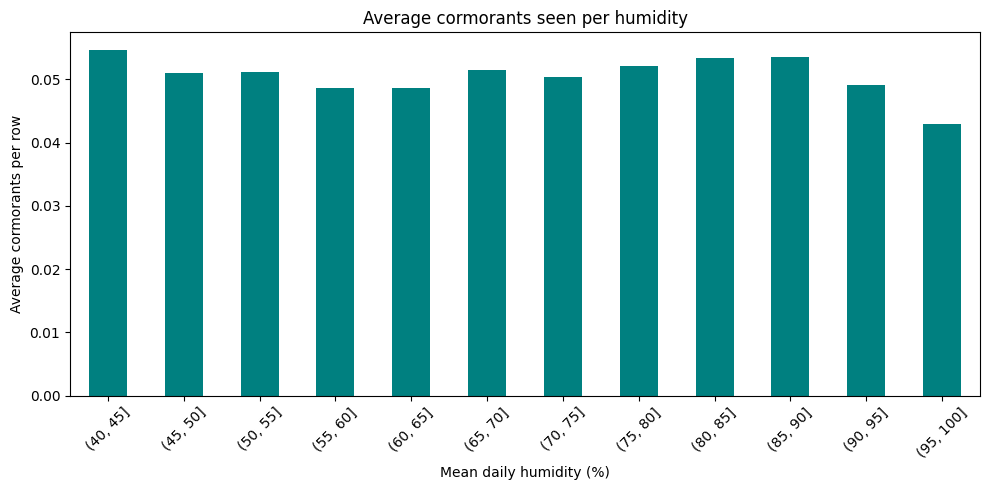

In [ ]:
plot_df = df[["UG", "Phalacrocorax carbo"]].dropna().copy()
plot_df["UG_bin"] = pd.cut(plot_df["UG"], bins=range(40, 101, 5))
hum_means = plot_df.groupby("UG_bin", observed=True)["Phalacrocorax carbo"].mean()

plt.figure(figsize=(10, 5))
hum_means.plot(kind="bar", color="teal")
plt.title("Average cormorants seen per humidity")
plt.xlabel("Mean daily humidity (%)")
plt.ylabel("Average cormorants per row")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Cormorants seen vs rain

Group days into 4 buckets - none / light / moderate / heavy - and check average sightings per bucket.

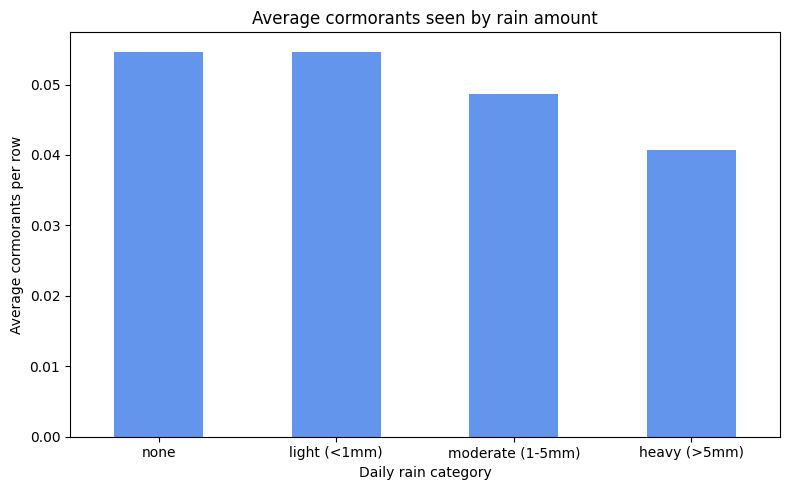

In [ ]:
plot_df = df[["RH", "Phalacrocorax carbo"]].dropna().copy()
plot_df["rain_cat"] = pd.cut(
    plot_df["RH"],
    bins=[-0.1, 0, 1, 5, 1000],
    labels=["none", "light (<1mm)", "moderate (1-5mm)", "heavy (>5mm)"],
)
rain_means = plot_df.groupby("rain_cat", observed=True)["Phalacrocorax carbo"].mean()

plt.figure(figsize=(8, 5))
rain_means.plot(kind="bar", color="cornflowerblue")
plt.title("Average cormorants seen by rain amount")
plt.xlabel("Daily rain category")
plt.ylabel("Average cormorants per row")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Cormorants seen vs wind

Binned by daily mean wind speed (`FG`, in m/s).

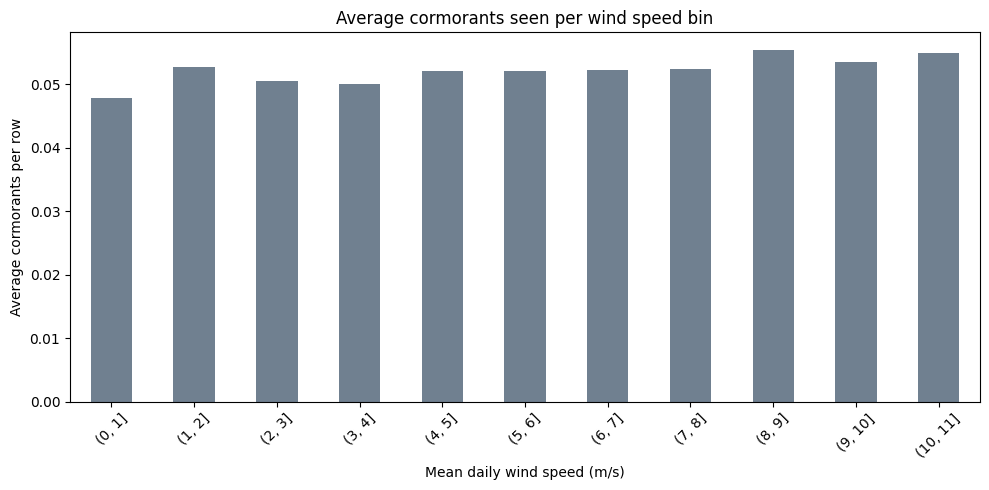

In [ ]:
plot_df = df[["FG", "Phalacrocorax carbo"]].dropna().copy()
plot_df["FG_bin"] = pd.cut(plot_df["FG"], bins=np.arange(0, 12, 1))
wind_means = plot_df.groupby("FG_bin", observed=True)["Phalacrocorax carbo"].mean()

plt.figure(figsize=(10, 5))
wind_means.plot(kind="bar", color="slategray")
plt.title("Average cormorants seen per wind speed bin")
plt.xlabel("Mean daily wind speed (m/s)")
plt.ylabel("Average cormorants per row")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Cormorants seen by month

Cormorants are migratory. We expect a clear seasonal pattern here - this is usually one of the strongest signals in any bird-sighting dataset.

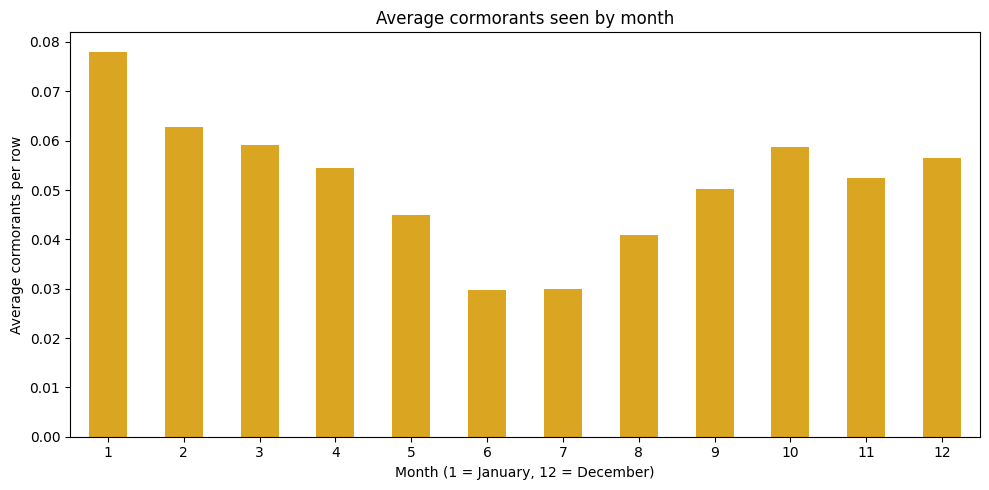

In [ ]:
month_means = df.groupby("month")["Phalacrocorax carbo"].mean()

plt.figure(figsize=(10, 5))
month_means.plot(kind="bar", color="goldenrod")
plt.title("Average cormorants seen by month")
plt.xlabel("Month (1 = January, 12 = December)")
plt.ylabel("Average cormorants per row")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Cormorants seen by day of year

Same idea, but at daily resolution. Catches finer migration patterns inside each month.

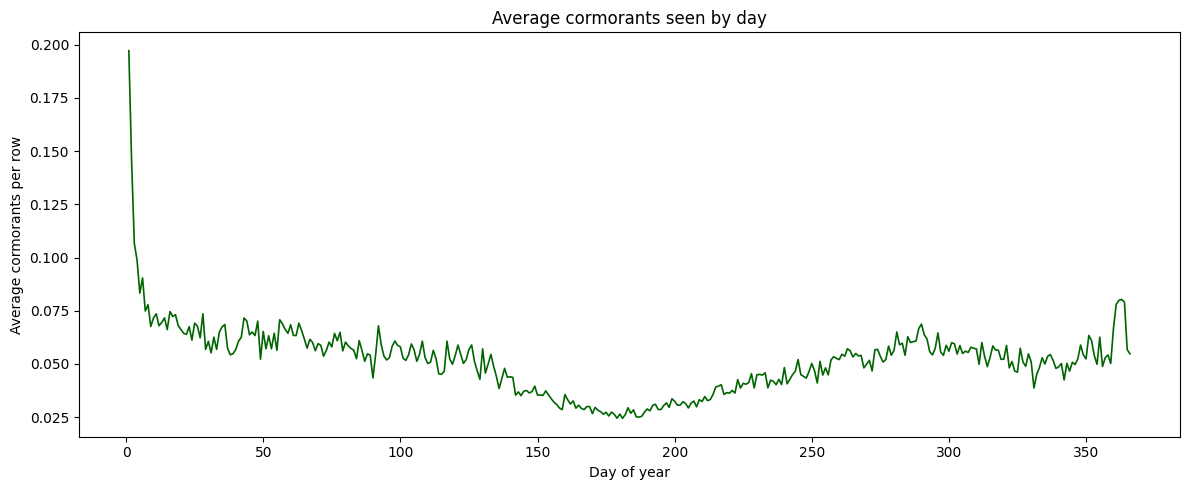

In [ ]:
doy_means = df.groupby("day_of_year")["Phalacrocorax carbo"].mean()

plt.figure(figsize=(12, 5))
doy_means.plot(color="darkgreen", linewidth=1.2)
plt.title("Average cormorants seen by day")
plt.xlabel("Day of year")
plt.ylabel("Average cormorants per row")
plt.tight_layout()
plt.show()

## Cormorants seen by year


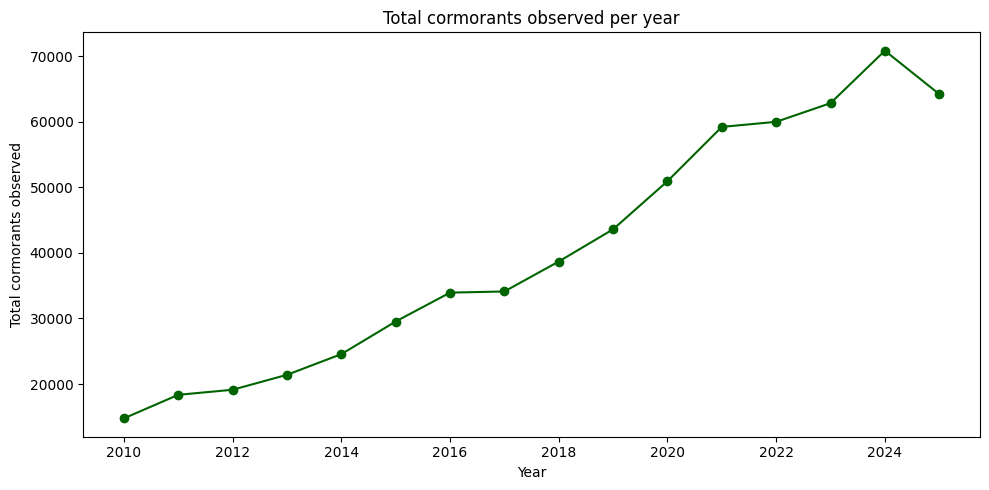

In [ ]:
yearly = df.groupby(df["eventDate"].dt.year)["Phalacrocorax carbo"].sum()

plt.figure(figsize=(10, 5))
yearly.plot(kind="line", marker="o", color="darkgreen")
plt.title("Total cormorants observed per year")
plt.xlabel("Year")
plt.ylabel("Total cormorants observed")
plt.tight_layout()
plt.show()

## Cormorants per month over time


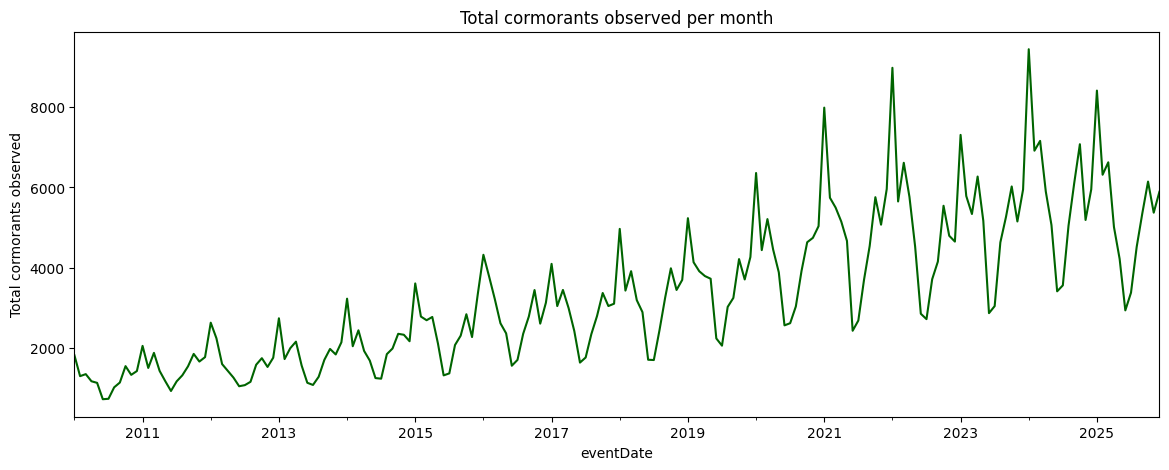

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df_plot = pd.read_parquet("bird_habitats_weather.parquet")

monthly = df_plot.groupby(df_plot["eventDate"].dt.to_period("M"))["Phalacrocorax carbo"].sum()

monthly.plot(figsize=(14, 5), color="darkgreen")
plt.title("Total cormorants observed per month")
plt.ylabel("Total cormorants observed")
plt.show()

## Insights ##
-